# Mapper Algorithm — Neighborhood Vulnerability Network

This notebook builds a **topological network of vulnerable neighborhoods** using the Mapper algorithm (TDA).  
It combines:
- Fire station neighborhood vulnerability scores
- Fire hydrant neighborhood vulnerability scores
- Social Vulnerability Index (SVI)
- Heat Vulnerability Index (HVI)

**Output:** An interactive graph where nodes = clusters of similar neighborhoods, edges = shared members between clusters.

In [ ]:
# Run once — restart kernel after installation
# !pip install kmapper scikit-learn umap-learn networkx pandas numpy matplotlib pyvis

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import networkx as nx

from sklearn.preprocessing import MinMaxScaler
from sklearn.decomposition import PCA
from sklearn.cluster import DBSCAN

import kmapper as km

import warnings
warnings.filterwarnings('ignore')

print('All imports OK')

All imports OK


## Load Data 
| Column | Description |
|---|---|
| `neighborhood_id` | Unique ID or name |
| `fire_station_score` | Coverage score 0–1 (1 = full coverage) |
| `hydrant_score` | Hydrant coverage score 0–1 |
| `svi_score` | CDC SVI overall score 0–1 (1 = most vulnerable) |
| `hvi_score` | Heat Vulnerability Index 0–1 (1 = most vulnerable) |

In [ ]:
fs_raw = pd.read_csv("../results/firestation_neighborhood_vulnerability.csv")
hy_raw = pd.read_csv("../results/hydrant_neighborhood_vulnerability.csv")
hvi_svi_raw = pd.read_csv("../data/hvi_svi.csv")

print(f'Fire station rows : {len(fs_raw)}')
print(f'Hydrant rows      : {len(hy_raw)}')
print(f'HVI/SVI rows      : {len(hvi_svi_raw)}')

Fire station rows : 272
Hydrant rows      : 272
HVI/SVI rows      : 2019


In [10]:
# ── Clean HVI/SVI ──────────────────────────────────────────────────────────
# CDC SVI uses -999 as a sentinel for suppressed/missing tracts
hvi_svi = (
    hvi_svi_raw
    .loc[hvi_svi_raw['RPL_THEMES'] >= 0]   # drop SVI sentinel
    .dropna(subset=['hvi'])                 # drop tracts with no HVI
    .copy()
)
print(f'HVI/SVI after cleaning: {len(hvi_svi)} tracts '
      f'(dropped {len(hvi_svi_raw) - len(hvi_svi)})')

# ── Aggregate census tracts to neighborhood/city level ─────────────────────
city_agg = (
    hvi_svi
    .groupby('census_city')
    .agg(
        hvi      = ('hvi',        'mean'),
        svi      = ('RPL_THEMES', 'mean'),
        n_tracts = ('census_city','count'),
    )
    .reset_index()
    .rename(columns={'census_city': 'neighborhood'})
)
print(f'Unique cities/neighborhoods with HVI+SVI: {len(city_agg)}')

HVI/SVI after cleaning: 1996 tracts (dropped 23)
Unique cities/neighborhoods with HVI+SVI: 119


In [11]:
# ── Normalize join keys (lowercase + strip whitespace) ─────────────────────
for frame in [fs_raw, hy_raw, city_agg]:
    frame['neighborhood'] = frame['neighborhood'].str.strip().str.lower()

# ── Inner join: HVI/SVI first, then fire station, then hydrant ─────────────
df = (
    city_agg
    .merge(
        fs_raw[['neighborhood', 'coverage_gap_score',
                'min_station_dist_km', 'n_stations_8km']],
        on='neighborhood', how='inner'
    )
    .rename(columns={'coverage_gap_score': 'fire_gap'})
    .merge(
        hy_raw[['neighborhood', 'coverage_gap_score',
                'min_hydrant_dist_m', 'n_hydrants_500m']],
        on='neighborhood', how='inner'
    )
    .rename(columns={'coverage_gap_score': 'hydrant_gap'})
    .reset_index(drop=True)
)

print(f'Final dataset: {len(df)} neighborhoods with HVI + SVI + fire gap + hydrant gap')
df.head(8)

Final dataset: 107 neighborhoods with HVI + SVI + fire gap + hydrant gap


,neighborhood,hvi,svi,n_tracts,fire_gap,min_station_dist_km,n_stations_8km,hydrant_gap,min_hydrant_dist_m,n_hydrants_500m
0,alhambra,38.498462,0.631885,13,0.2004,0.801,28,0.2198,2301.5,0
1,altadena,26.231667,0.463817,6,0.2019,0.598,16,0.2585,7056.7,0
2,arcadia,27.548889,0.372889,9,0.2025,0.648,21,0.2961,11602.3,0
3,artesia,41.296667,0.724567,3,0.1911,1.121,16,0.3218,14703.4,0
4,avalon,36.825000,0.437000,2,0.7000,42.790,0,0.5436,41453.8,0
5,azusa,43.430909,0.685118,11,0.2054,0.778,12,0.3899,22912.4,0
6,baldwin park,46.552857,0.718729,14,0.2089,1.395,20,0.3410,17017.6,0
7,bellflower,50.090000,0.802625,12,0.1989,0.720,24,0.2854,10304.4,0


### EDA

In [12]:
analysis_cols = ['hvi', 'svi', 'fire_gap', 'hydrant_gap']
display(df[analysis_cols].describe().round(3))

,hvi,svi,fire_gap,hydrant_gap
count,107.000,107.000,107.000,107.000
mean,35.939,0.490,0.215,0.275
std,12.099,0.241,0.060,0.099
min,11.060,0.059,0.070,0.148
25%,26.267,0.311,0.200,0.199
50%,35.115,0.522,0.205,0.236
75%,45.782,0.702,0.215,0.323
max,60.119,0.891,0.700,0.580


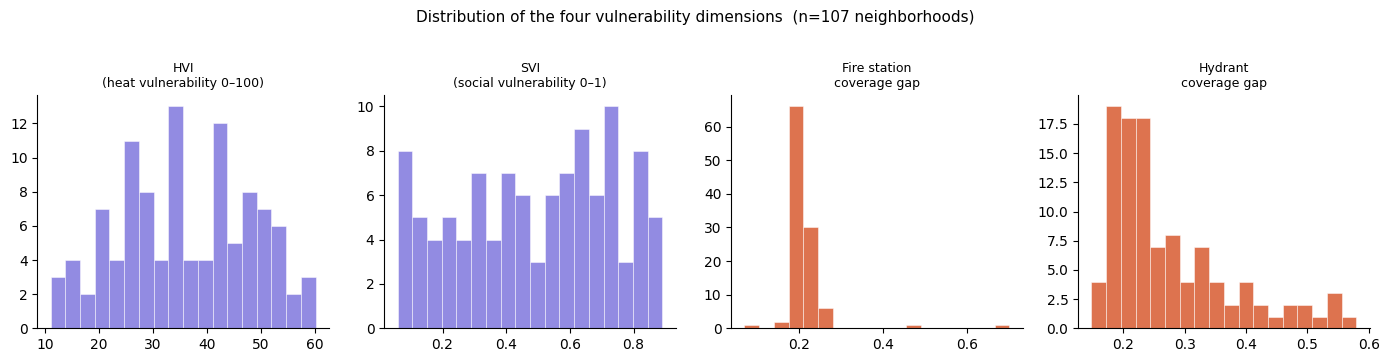

In [13]:
fig, axes = plt.subplots(1, 4, figsize=(14, 3.5))
palette    = ['#7F77DD', '#7F77DD', '#D85A30', '#D85A30']
col_labels = [
    'HVI\n(heat vulnerability 0–100)',
    'SVI\n(social vulnerability 0–1)',
    'Fire station\ncoverage gap',
    'Hydrant\ncoverage gap',
]
for ax, col, color, label in zip(axes, analysis_cols, palette, col_labels):
    ax.hist(df[col], bins=18, color=color, alpha=0.85,
            edgecolor='white', linewidth=0.4)
    ax.set_title(label, fontsize=9)
    ax.spines[['top', 'right']].set_visible(False)

plt.suptitle('Distribution of the four vulnerability dimensions  (n=107 neighborhoods)',
             y=1.02, fontsize=11)
plt.tight_layout()
plt.show()

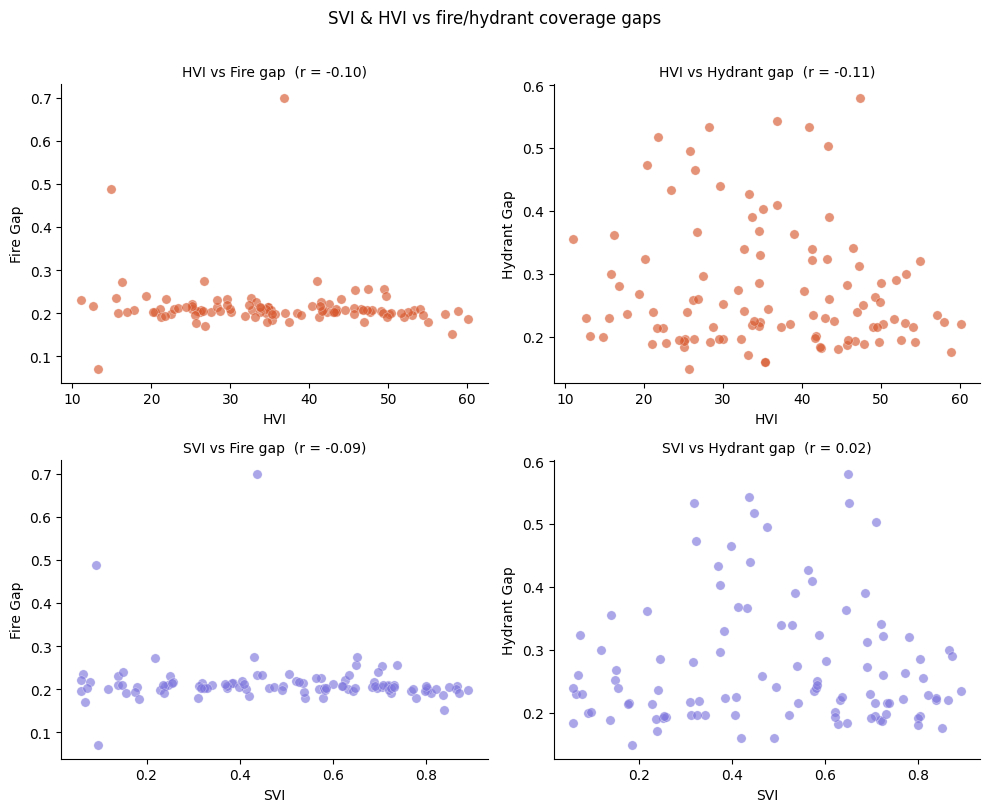

In [14]:
# HVI / SVI vs coverage gaps
fig, axes = plt.subplots(2, 2, figsize=(10, 8))
pairs = [
    ('hvi', 'fire_gap',    'HVI vs Fire gap',    '#D85A30'),
    ('hvi', 'hydrant_gap', 'HVI vs Hydrant gap', '#D85A30'),
    ('svi', 'fire_gap',    'SVI vs Fire gap',    '#7F77DD'),
    ('svi', 'hydrant_gap', 'SVI vs Hydrant gap', '#7F77DD'),
]
for ax, (x, y, title, color) in zip(axes.flat, pairs):
    ax.scatter(df[x], df[y], c=color, alpha=0.65, s=45,
               edgecolors='white', linewidth=0.3)
    r = df[[x, y]].corr().iloc[0, 1]
    ax.set_xlabel(x.upper(), fontsize=10)
    ax.set_ylabel(y.replace('_', ' ').title(), fontsize=10)
    ax.set_title(f'{title}  (r = {r:.2f})', fontsize=10)
    ax.spines[['top', 'right']].set_visible(False)

plt.suptitle('SVI & HVI vs fire/hydrant coverage gaps', fontsize=12, y=1.01)
plt.tight_layout()
plt.show()

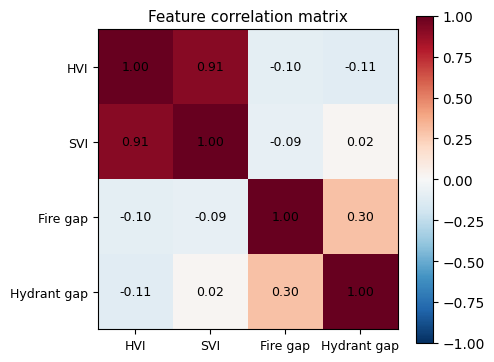

In [15]:
corr = df[analysis_cols].corr()
fig, ax = plt.subplots(figsize=(5, 4))
im = ax.imshow(corr, cmap='RdBu_r', vmin=-1, vmax=1)
labels_short = ['HVI', 'SVI', 'Fire gap', 'Hydrant gap']
ax.set_xticks(range(4)); ax.set_yticks(range(4))
ax.set_xticklabels(labels_short, fontsize=9)
ax.set_yticklabels(labels_short, fontsize=9)
plt.colorbar(im, ax=ax)
for i in range(4):
    for j in range(4):
        ax.text(j, i, f'{corr.iloc[i,j]:.2f}', ha='center', va='center', fontsize=9)
ax.set_title('Feature correlation matrix', fontsize=11)
plt.tight_layout()
plt.show()

## Build Mapper Matrix

In [16]:
feature_cols = ['hvi', 'svi', 'fire_gap', 'hydrant_gap']

scaler = MinMaxScaler()
X = scaler.fit_transform(df[feature_cols])

print(f'Feature matrix shape: {X.shape}  — rows=neighborhoods, cols={feature_cols}')
print(pd.DataFrame(X, columns=feature_cols).describe().round(3))

Feature matrix shape: (107, 4)  — rows=neighborhoods, cols=['hvi', 'svi', 'fire_gap', 'hydrant_gap']
           hvi      svi  fire_gap  hydrant_gap
count  107.000  107.000   107.000      107.000
mean     0.507    0.518     0.230        0.293
std      0.247    0.290     0.095        0.230
min      0.000    0.000     0.000        0.000
25%      0.310    0.304     0.206        0.117
50%      0.490    0.557     0.215        0.203
75%      0.708    0.773     0.231        0.405
max      1.000    1.000     1.000        1.000


## Run the Mapper Algo

Lens: 2-D projection on HVI × SVI

The lens is built from the **first two scaled columns** (HVI and SVI).  
Mapper slices the vulnerability space along these axes, then examines how fire and hydrant gaps distribute within each slice.

Lens shape: (107, 2)


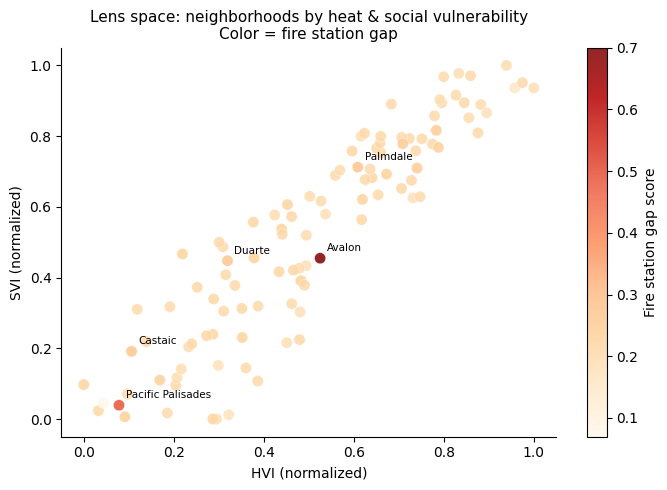

In [17]:
mapper = km.KeplerMapper(verbose=0)

# Lens = scaled HVI (col 0) and SVI (col 1)
lens = X[:, :2]   # shape (107, 2)

print(f'Lens shape: {lens.shape}')

fig, ax = plt.subplots(figsize=(7, 5))
sc = ax.scatter(
    lens[:, 0], lens[:, 1],
    c=df['fire_gap'], cmap='OrRd',
    s=65, alpha=0.85, edgecolors='white', linewidth=0.3
)
# Label a few extreme neighborhoods
for _, row in df.nlargest(5, 'fire_gap').iterrows():
    idx = df.index.get_loc(_)
    ax.annotate(
        row['neighborhood'].title(),
        (lens[idx, 0], lens[idx, 1]),
        fontsize=7.5, xytext=(5, 5), textcoords='offset points'
    )
plt.colorbar(sc, ax=ax, label='Fire station gap score')
ax.set_xlabel('HVI (normalized)', fontsize=10)
ax.set_ylabel('SVI (normalized)', fontsize=10)
ax.set_title('Lens space: neighborhoods by heat & social vulnerability\n'
             'Color = fire station gap', fontsize=11)
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.show()

In [18]:
# ── Tunable parameters ─────────────────────────────────────────────────────
N_CUBES      = 8     # intervals per lens axis (8×8 = 64 bins over the 2-D lens)
PERC_OVERLAP = 0.5   # fraction of overlap between adjacent bins
DBSCAN_EPS   = 0.4   # DBSCAN neighbourhood radius in scaled space
DBSCAN_MIN   = 2     # min samples to form a cluster

graph = mapper.map(
    lens,
    X,
    cover=km.Cover(n_cubes=N_CUBES, perc_overlap=PERC_OVERLAP),
    clusterer=DBSCAN(eps=DBSCAN_EPS, min_samples=DBSCAN_MIN)
)

n_nodes = len(graph['nodes'])
n_edges = sum(len(v) for v in graph['links'].values())
print(f'Mapper graph  →  nodes: {n_nodes}   edges: {n_edges}')

Mapper graph  →  nodes: 36   edges: 102


## Visualization


In [26]:
betweenness  = nx.betweenness_centrality(G, weight='weight')
degree_cent  = nx.degree_centrality(G)
bridge_edges = list(nx.bridges(G)) if nx.is_connected(G) else []

for node in G.nodes():
    G.nodes[node]['betweenness'] = betweenness[node]
    G.nodes[node]['degree_cent'] = degree_cent[node]

node_df = pd.DataFrame([
    {
        'node'           : n,
        'n_neighborhoods': d['size'],
        'neighborhoods'  : ', '.join(x.title() for x in d['neighborhoods'][:5])
                           + ('…' if d['size'] > 5 else ''),
        'mean_hvi'       : round(d['mean_hvi'], 1),
        'mean_svi'       : round(d['mean_svi'], 3),
        'fire_gap'       : round(d['mean_fire_gap'], 4),
        'hydrant_gap'    : round(d['mean_hydrant_gap'], 4),
        'betweenness'    : round(d['betweenness'], 4),
        'composite_risk' : round(d['composite_risk'], 3),
    }
    for n, d in G.nodes(data=True)
]).sort_values('composite_risk', ascending=False).reset_index(drop=True)

print('All Mapper nodes ranked by composite risk:')
display(node_df.head(10))
print(f'\nBridge edges: {bridge_edges if bridge_edges else "none"}')

All Mapper nodes ranked by composite risk:


,node,n_neighborhoods,neighborhoods,mean_hvi,mean_svi,fire_gap,hydrant_gap,betweenness,composite_risk
0,cube38_cluster0,11,"Compton, El Monte, Hawaiian Gardens, Hawthorne...",55.1,0.829,0.1919,0.2362,0.0000,0.555
1,cube35_cluster0,12,"Bellflower, El Monte, Hawaiian Gardens, Hawtho...",51.7,0.808,0.2016,0.2486,0.0368,0.543
2,cube37_cluster0,8,"Hawaiian Gardens, Hawthorne, Huntington Park, ...",54.8,0.797,0.1902,0.2269,0.0504,0.538
3,cube31_cluster0,6,"Bellflower, Lynwood, Montebello, Paramount, Sa...",48.9,0.798,0.2089,0.2364,0.2406,0.522
4,cube34_cluster0,17,"Baldwin Park, Bellflower, Gardena, Hawaiian Ga...",50.1,0.752,0.2088,0.2365,0.0836,0.514
5,cube30_cluster0,24,"Artesia, Azusa, Baldwin Park, Bellflower, Carson…",45.2,0.711,0.2152,0.2870,0.0000,0.508
6,cube26_cluster0,13,"Alhambra, Artesia, Azusa, Carson, Downey…",42.0,0.690,0.2112,0.2985,0.2717,0.490
7,cube29_cluster0,28,"Artesia, Azusa, Baldwin Park, Canoga Park, Car...",44.3,0.659,0.2138,0.2834,0.0210,0.485
8,cube33_cluster0,12,"Baldwin Park, Gardena, Inglewood, Lawndale, Lo...",47.8,0.673,0.2106,0.2343,0.0334,0.477
9,cube25_cluster0,22,"Alhambra, Artesia, Azusa, Canoga Park, Carson…",40.4,0.632,0.2103,0.3030,0.0106,0.467



Bridge edges: none


In [30]:
G = nx.Graph()

# Pre-compute a normalized version of all four features for composite risk
X_norm_df = pd.DataFrame(
    MinMaxScaler().fit_transform(df[feature_cols]),
    columns=feature_cols
)

for node_id, member_idx in graph['nodes'].items():
    subset      = df.iloc[member_idx]
    subset_norm = X_norm_df.iloc[member_idx]
    G.add_node(
        node_id,
        size             = len(member_idx),
        neighborhoods    = subset['neighborhood'].tolist(),
        mean_hvi         = subset['hvi'].mean(),
        mean_svi         = subset['svi'].mean(),
        mean_fire_gap    = subset['fire_gap'].mean(),
        mean_hydrant_gap = subset['hydrant_gap'].mean(),
        mean_station_dist= subset['min_station_dist_km'].mean(),
        mean_hydrant_dist= subset['min_hydrant_dist_m'].mean(),
        composite_risk   = subset_norm.mean().mean(),   # avg across all 4 norm dims
    )

for src, targets in graph['links'].items():
    for tgt in targets:
        if not G.has_edge(src, tgt):
            shared = set(graph['nodes'][src]) & set(graph['nodes'][tgt])
            G.add_edge(src, tgt, weight=len(shared))

print(f'NetworkX graph  →  nodes: {G.number_of_nodes()}   edges: {G.number_of_edges()}')
print(f'Connected components: {nx.number_connected_components(G)}')

NetworkX graph  →  nodes: 36   edges: 102
Connected components: 1


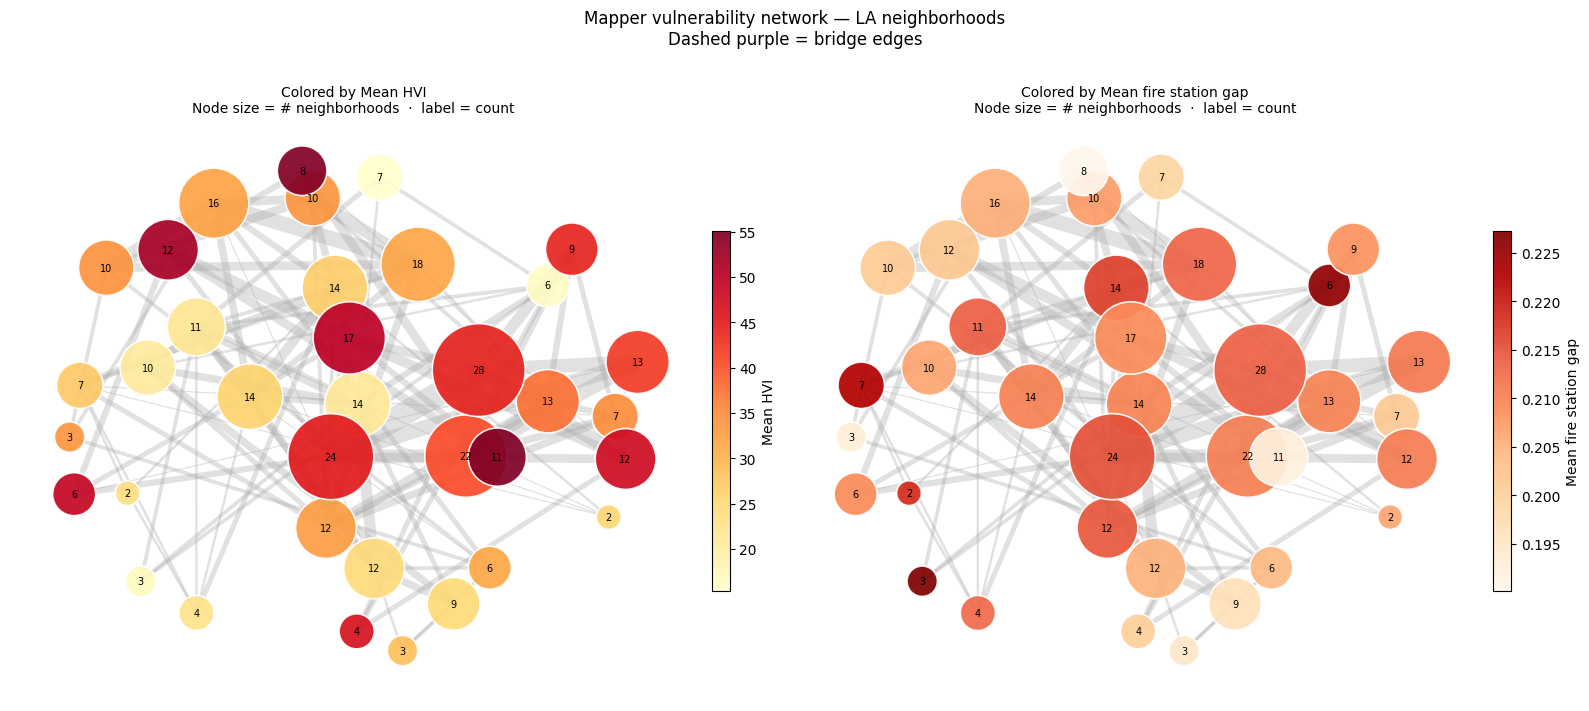

In [31]:
fig, axes = plt.subplots(1, 2, figsize=(16, 7))
pos = nx.spring_layout(G, seed=42, k=3)

node_sizes  = [G.nodes[n]['size'] * 160 for n in G.nodes()]
edge_widths = [G[u][v]['weight'] * 0.9 for u, v in G.edges()]

for ax, color_attr, cmap, cbar_label in [
    (axes[0], 'mean_hvi',      'YlOrRd', 'Mean HVI'),
    (axes[1], 'mean_fire_gap', 'OrRd',   'Mean fire station gap'),
]:
    vals = [G.nodes[n][color_attr] for n in G.nodes()]
    nx.draw_networkx_edges(G, pos, ax=ax, width=edge_widths,
                           alpha=0.35, edge_color='#aaa')
    nodes = nx.draw_networkx_nodes(
        G, pos, ax=ax, node_size=node_sizes,
        node_color=vals, cmap=plt.get_cmap(cmap),
        alpha=0.92, linewidths=1.2, edgecolors='white'
    )
    if bridge_edges:
        nx.draw_networkx_edges(
            G, pos, edgelist=bridge_edges, ax=ax,
            width=2.5, edge_color='#7F77DD', style='dashed', alpha=0.85
        )
    labels = {n: str(G.nodes[n]['size']) for n in G.nodes()}
    nx.draw_networkx_labels(G, pos, labels=labels, font_size=7, ax=ax)
    plt.colorbar(nodes, ax=ax, label=cbar_label, fraction=0.025, pad=0.02)
    ax.set_title(
        f'Colored by {cbar_label}\nNode size = # neighborhoods  ·  label = count',
        fontsize=10)
    ax.axis('off')

plt.suptitle('Mapper vulnerability network — LA neighborhoods\n'
             'Dashed purple = bridge edges', fontsize=12, y=1.01)
plt.tight_layout()
# plt.savefig('mapper_static.png', dpi=150, bbox_inches='tight')
plt.show()
# print('Saved: mapper_static.png')

Coverage gap distribution by risk tier

Do neighborhoods that score high on HVI and SVI *also* have worse fire/hydrant coverage?

Mean scores by composite risk tier:


,fire_gap,hydrant_gap,mean_hvi,mean_svi
risk_tier,,,,
Low risk,0.207,0.244,23.550,0.212
Medium risk,0.210,0.312,32.167,0.446
High risk,0.207,0.278,45.908,0.700


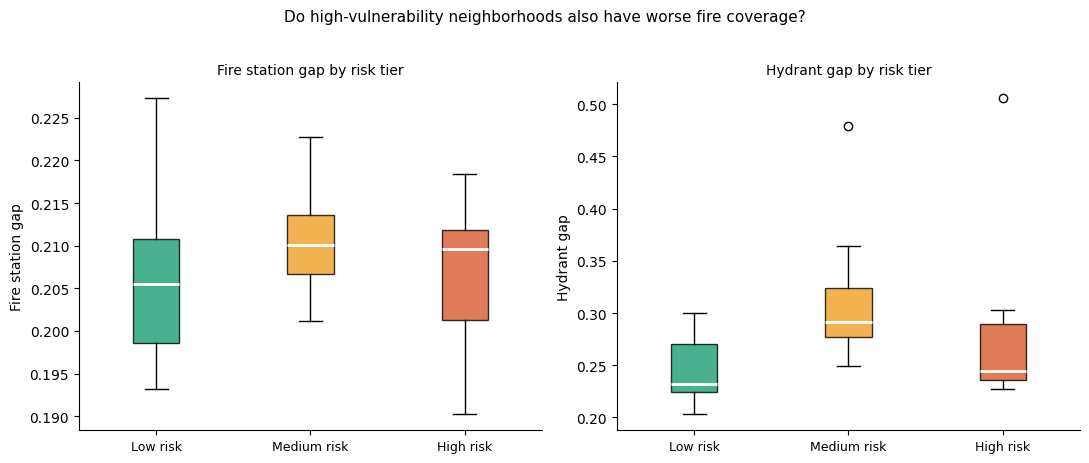

In [ ]:
node_df['risk_tier'] = pd.qcut(
    node_df['composite_risk'], q=3,
    labels=['Low risk', 'Medium risk', 'High risk']
)

tier_summary = (
    node_df.groupby('risk_tier')
    [['fire_gap', 'hydrant_gap', 'mean_hvi', 'mean_svi']]
    .mean().round(3)
)
print('Mean scores by composite risk tier:')
display(tier_summary)

fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
colors_tier = ['#1D9E75', '#EF9F27', '#D85A30']
tiers       = ['Low risk', 'Medium risk', 'High risk']

for ax, col, ylabel in [
    (axes[0], 'fire_gap',    'Fire station gap'),
    (axes[1], 'hydrant_gap', 'Hydrant gap'),
]:
    data = [node_df.loc[node_df['risk_tier'] == t, col].values for t in tiers]
    bp   = ax.boxplot(data, patch_artist=True,
                      medianprops=dict(color='white', linewidth=2))
    for patch, color in zip(bp['boxes'], colors_tier):
        patch.set_facecolor(color)
        patch.set_alpha(0.8)
    ax.set_xticklabels(tiers, fontsize=9)
    ax.set_ylabel(ylabel, fontsize=10)
    ax.set_title(f'{ylabel} by risk tier', fontsize=10)
    ax.spines[['top', 'right']].set_visible(False)

plt.suptitle(
    'Do high-vulnerability neighborhoods also have worse fire coverage?',
    fontsize=11, y=1.02
)
plt.tight_layout()
# plt.savefig('coverage_by_risk_tier.png', dpi=150, bbox_inches='tight')
plt.show()